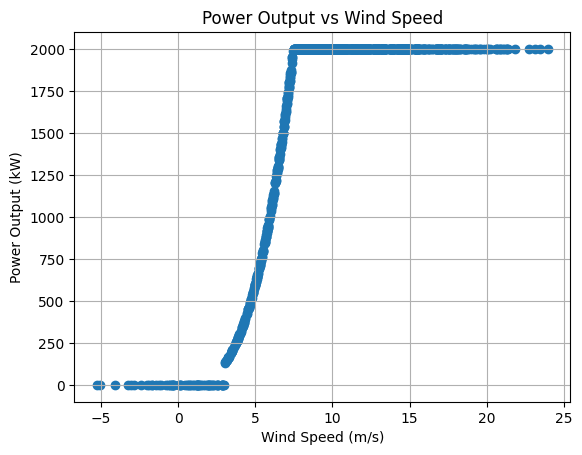

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Data Acquisition - Generate synthetic wind speed data
numSamples = 1000
windSpeed = 10 + 5 * np.random.randn(numSamples)  # Mean: 10 m/s, Std: 5 m/s

# Step 2: Modeling - Turbine parameters
bladeLength = 50  # meters
turbineHeight = 80  # meters

# Function to calculate power output
def calculatePowerOutput(windSpeed, bladeLength):
    ratedPower = 2000  # kW
    cutInWindSpeed = 3  # m/s
    cutOutWindSpeed = 25  # m/s

    powerOutput = np.zeros_like(windSpeed)

    validIndices = (windSpeed >= cutInWindSpeed) & (windSpeed <= cutOutWindSpeed)

    powerOutput[validIndices] = (
        0.5 * 1.225 * np.pi * bladeLength**2 * windSpeed[validIndices]**3 * 1e-3
    )

    # Apply rated power limit
    powerOutput = np.minimum(powerOutput, ratedPower)

    return powerOutput

# Step 3: Simulation
powerOutput = calculatePowerOutput(windSpeed, bladeLength)

# Step 4: Analysis - Plot
plt.figure()
plt.scatter(windSpeed, powerOutput)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')
plt.title('Power Output vs Wind Speed')
plt.grid()

plt.show()
